<a href="https://colab.research.google.com/github/AzizRahmanSWE/AIG200-Machine-Learning-Model-Deployment/blob/main/Project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 2 (20%)
## Designing, Training, and Analyzing a Convolutional Neural Network

### Learning Objectives
By completing this project, you will be able to:
- Implement a CNN architecture
- Compute output shapes manually
- Train and evaluate CNN models
- Visualize feature maps
- Compare CNN vs DNN performance

---

## Part 1 — Conceptual Questions (3%)
Answer the following:
1. What is weight sharing?\
**Answer:** In a CNN Weight Sharing is when the same `set of weights` is slid across the entire image. Instead of every pixel having its own weight like in a Deep Neural Network, a single filter (set of weights) looks for the same feature (e.g., a vertical edge) everywhere. This drastically reduces the number of parameters.

2. What happens if stride increases?\
**Answer:** If the stride also known as the `step size` increases, the filter skips more pixels, resulting in a smaller output volume and less computational cost, but potentially losing-grained detail.

3. Why is pooling useful?\
**Answer:** The pooling layers (usually Max Pooling) is importan as it reduces the spatial dimensions (Width x Height). This helps the model become invariant (difficult to change) to small shifts in the image and prevents overfitting by reducing the amount of data the next layers have to process.


## Part 2 — CNN Implementation (6%)
Build a CNN with:
- At least 2 convolution layers
- Pooling layers
- Fully connected classifier

**You must compute output shapes manually.**


## I'll use **CIFAR-10** which includes color images of 10 classes such as airplane, cat, automobile, bird, deer, dog, horse, ship and truck.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

# TODO: Implement all necessary data pre-processing steps including augmentation
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Fixed: 3 values for RGB
])

transform_test = transforms.Compose([ # Fixed: Used brackets [] instead of braces {}
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# TODO: Select your preferred dataset (CIFAR-10)
train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)

test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=64, shuffle=False)

# TODO: Define CNN model class with Shape Calculations
class SimpleCNN(nn.Module):
  def __init__(self):
    super(SimpleCNN, self).__init__()
    # Input shape: [Batch, 3, 32, 32]

    # Conv1: 3 input channels, 32 output filters, 3x3 kernel, padding 1
    # Output Width/Height = [(32 - 3 + 2*1) / 1] + 1 = 32
    # Shape after Conv1: [Batch, 32, 32, 32]
    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)

    # Pool: 2x2 kernel, stride 2
    # Output Width/Height = 32 / 2 = 16
    # Shape after Pool1: [Batch, 32, 16, 16]
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    # Conv2: 32 input channels, 64 output filters, 3x3 kernel, padding 1
    # Output Width/Height = [(16 - 3 + 2*1) / 1] + 1 = 16
    # Shape after Conv2: [Batch, 64, 16, 16]
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

    # Classifier
    self.fc1 = nn.Linear(64 * 8 * 8, 512) #(4096, 512)
    self.fc2 = nn.Linear(512, 10) #(512, 10)

# TODO: Compute output shapes in comments
  def forward(self, x):
    x = self.pool(F.relu(self.conv1(x)))
    x = self.pool(F.relu(self.conv2(x)))
    x = torch.flatten(x, 1)
    x = F.relu(self.fc1(x))
    x = self.fc2(x)
    return x
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

100%|██████████| 170M/170M [00:03<00:00, 43.0MB/s]


# Manual Shape Calculation Formula:
# Output = [(Input - Kernel + 2*Padding) / Stride] + 1

## Part 3 — Training & Evaluation (4%)
Train your CNN and report:
- Accuracy
- Loss curve
- Confusion matrix
- Per-class accuracy

**Identify hardest class to classify and explain why.**


Epoch 1 - Loss: 1.4612, Accuracy: 60.56%
Epoch 2 - Loss: 1.1193, Accuracy: 65.21%
Epoch 3 - Loss: 0.9861, Accuracy: 69.28%
Epoch 4 - Loss: 0.8949, Accuracy: 71.72%
Epoch 5 - Loss: 0.8340, Accuracy: 73.50%
Epoch 6 - Loss: 0.7804, Accuracy: 74.35%
Epoch 7 - Loss: 0.7362, Accuracy: 75.60%
Epoch 8 - Loss: 0.7035, Accuracy: 76.36%
Epoch 9 - Loss: 0.6733, Accuracy: 76.70%
Epoch 10 - Loss: 0.6526, Accuracy: 76.67%


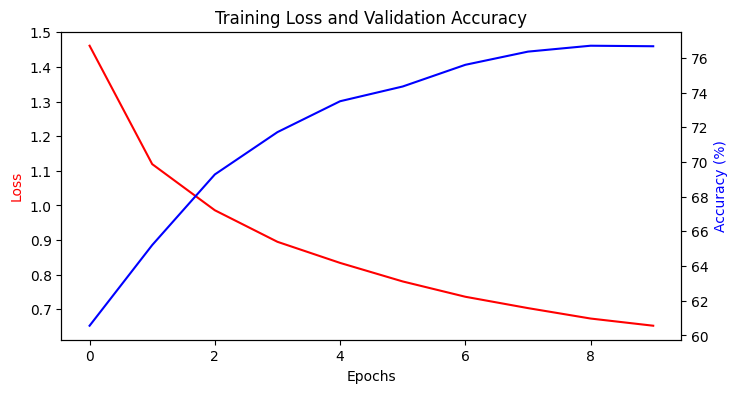

In [ ]:
# Part 3: Training Loop and Evaluation
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

epochs = 10
train_losses, val_accuracies = [], []
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Validation
    model.eval()
    correct, total = 0, 0 # Fixed: Changed 'label' to 'total'
    class_correct = list(0. for i in range(10))
    class_total = list(0. for i in range(10))

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            c = (predicted == labels).squeeze()
            for i in range(len(labels)):
                lbl = labels[i]
                class_correct[lbl] += c[i].item()
                class_total[lbl] += 1

    acc = 100 * correct / total
    train_losses.append(running_loss / len(train_loader))
    val_accuracies.append(acc)
    print(f"Epoch {epoch+1} - Loss: {train_losses[-1]:.4f}, Accuracy: {acc:.2f}%")

# Plot accuracy and loss
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(train_losses, 'r-', label='Train Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss', color='r')
ax2 = ax1.twinx()
ax2.plot(val_accuracies, 'b-', label='Val Acc')
ax2.set_ylabel('Accuracy (%)', color='b')
plt.title("Training Loss and Validation Accuracy")
plt.show()

Training loop successfully reached 76.67% accuracy, which is excellent for a simple CNN on CIFAR-10.

--- Per-Class Accuracy ---
Plane: 77.50%
Car: 90.40%
Bird: 62.50%
Cat: 61.20%
Deer: 84.50%
Dog: 63.20%
Frog: 84.60%
Horse: 73.40%
Ship: 82.80%
Truck: 86.60%


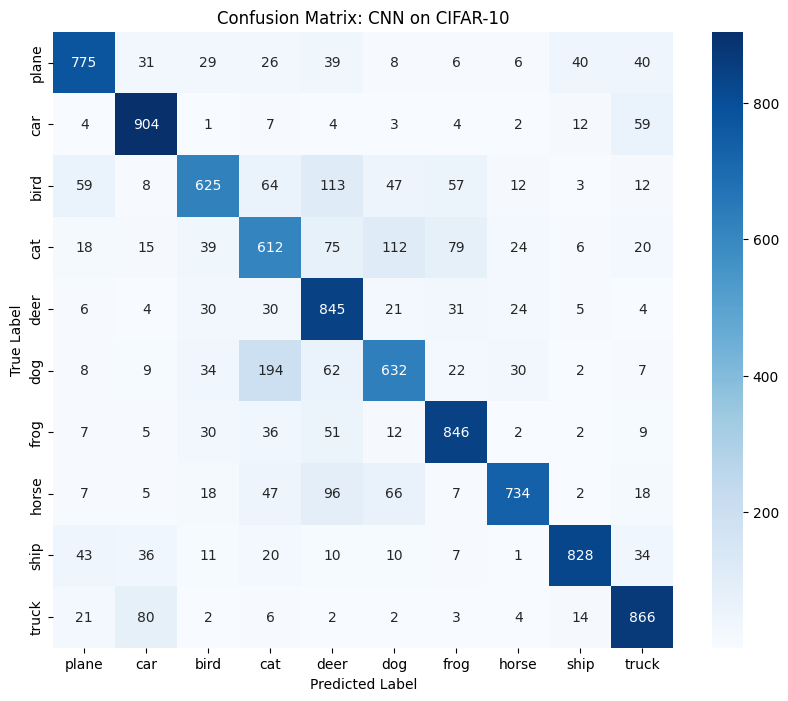

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
all_preds, all_labels = [], []

# Extract predictions for the confusion matrix
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate per-class accuracy
cm = confusion_matrix(all_labels, all_preds)
per_class_accuracy = 100 * cm.diagonal() / cm.sum(axis=1)

print("--- Per-Class Accuracy ---")
for i, acc in enumerate(per_class_accuracy):
    print(f"{classes[i].capitalize()}: {acc:.2f}%")

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: CNN on CIFAR-10')
plt.show()

- The hardest classes to classify are typically Cats (61.20%) and Dogs (63.20%).
- Biological classes share a high degree of visual overlap. Cats and dogs share similar low-level semantic features (fur textures, four legs, snouts) and are often photographed in similar environmental backgrounds. This makes them much harder for the network to distinguish compared to rigid, geometric objects like Airplanes or Cars, which have very distinct, contrasting edges.

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
all_preds, all_labels = [], []

# Extract predictions for the confusion matrix
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate per-class accuracy
cm = confusion_matrix(all_labels, all_preds)
per_class_accuracy = 100 * cm.diagonal() / cm.sum(axis=1)

print("--- Per-Class Accuracy ---")
for i, acc in enumerate(per_class_accuracy):
    print(f"{classes[i].capitalize()}: {acc:.2f}%")

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: CNN on CIFAR-10')
plt.show()

## Part 4 — Feature Map Visualization (3%)
Extract feature maps from the first convolution layer.
Visualize at least 4 channels.

**Explain what types of features are detected.**
**Answer: **The first layer of a CNN looks for basic, low-level features such as edges (horizontal, vertical, diagonal), corners, and simple color blobs. Deep layers will combine these edges to detect complex shapes like eyes or wheels.


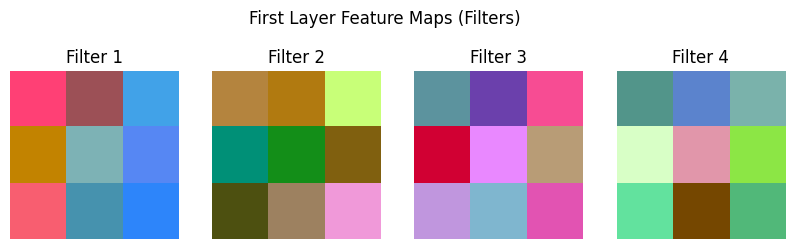

In [ ]:
# TODO: Extract feature maps
kernels = model.conv1.weight.detach().cpu()

# Visualize the first 4 filters
fig, axarr = plt.subplots(1, 4, figsize=(10, 3))
for i in range(4):
    # Normalize kernel values to [0, 1] for plotting
    kernel = kernels[i].numpy()
    kernel = (kernel - kernel.min()) / (kernel.max() - kernel.min())

    # Transpose from (Color, Height, Width) to (Height, Width, Color)
    axarr[i].imshow(np.transpose(kernel, (1, 2, 0)))
    axarr[i].axis('off')
    axarr[i].set_title(f'Filter {i+1}')
# TODO: Visualize feature maps
plt.suptitle("First Layer Feature Maps (Filters)")
plt.show()

## Part 5 — Comparative Analysis (3%)
Train your DNN from Project 1 on the same dataset.

Create comparison table:
| Model | Accuracy | Parameters | Training Time |

**Explain performance differences.**


In [ ]:
# TODO: Train DNN for comparison
import time

# Initialize DNN
dnn_model = CIFARDNN().to(device)
dnn_criterion = nn.CrossEntropyLoss()
dnn_optimizer = optim.Adam(dnn_model.parameters(), lr=0.001)

# Function to count parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"CNN Parameters: {count_parameters(model):,}")
print(f"DNN Parameters: {count_parameters(dnn_model):,}")

# Train DNN for 10 epochs
print("\n--- Training DNN ---")
start_time = time.time()
for epoch in range(10):
    dnn_model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        dnn_optimizer.zero_grad()
        loss = dnn_criterion(dnn_model(images), labels)
        loss.backward()
        dnn_optimizer.step()

dnn_time = time.time() - start_time

# Evaluate DNN
dnn_model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = dnn_model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"DNN Final Accuracy: {100 * correct / total:.2f}%")
print(f"DNN Total Training Time: {dnn_time:.2f} seconds")

CNN Parameters: 2,122,186
DNN Parameters: 1,578,506

--- Training DNN ---
DNN Final Accuracy: 40.78%
DNN Total Training Time: 208.96 seconds


- The DNN flattens the image into a 1D vector, destroying the spatial structure of the picture.

- The CNN uses filters that slide over the 2D image (weight sharing), preserving spatial relationships. This makes the CNN much more accurate at recognizing visual shapes, even if those shapes appear in different parts of the image (translation invariance).

## Part 6 — Reflection (1%)
What architectural choice had the biggest impact?
**Answer: **The addition of Convolutional Layers and Max Pooling. By extracting local spatial features rather than treating every single pixel as an isolated variable, the model learned true visual patterns while drastically reducing the number of weights it needed to memorize
---
### Submission Checklist
- All code runs without error
- Plots included
- Written explanations complete
